## 2 excitatory, 1 inhibitory neuron

#### Scheme:

    3 coupled neurons, 2 N_E and N_I
    Different inputs (static currents or sinusoids)
    Only one E neuron has an autapse
    The idea is to produce either winner-takes-all-dynamics or coherence.
    We can cut out some synapses in order to simulate different 2 neuron circuits...

#### Question:
    Can the autaptic neuron regulate the firing frequency of the other neurons?
    Can the autapse help produce shunting inhibition through the interneuron?
    Can N_E1 control the output frequency of N_I or N_E2?
    Can N_I control the output frequency of N_E1/2?
    Does the autapse play a role in this?
    
#### Parameters to vary:

    Inputs to each neuron Inj_e1, Inj_e2, Inj_i
    synapse strengths: Which neuron holds more influence? Can even sever some connections to create 2 neuron networks
    autapse strength: Can the behaviour change as the autapse is strengthened or weakened?

#### Metrics:

    -> compare to uncoupled system.
    -> compare to non-autaptic system.
    -> van Rossum distance? do the neurons synchronise better? Van rossum distance over time?
    -> Which neuron entrains which? Is there a way to show which neuron adapts more? 
    -> Frequency per neuron over time?

In [29]:

''' import aqua '''
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.utils import * 

'''general imports''' 
import numpy as np
import pandas as pd
from brian2 import *
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
I_neuron = {'name': 'FS', 'C': 20, 'k': 1, 'v_r': -55, 'v_t': -40, 'v_peak': 25,
     'a': 0.2, 'b': -2, 'c': -45, 'd': 0, 'e': 0., 'f': 0., 'tau': 0.}

# strong autaptic neuron on RS integrator...
E1_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 0.}     # instantaneous autapse bc all synapses are instant.

# non-autaptic neuron - RS integrator
E2_neuron = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

def visualise_connectivity(S):
    Ns = len(S.source)
    Nt = len(S.target)
    figure(figsize=(10, 4))
    subplot(121)
    plot(zeros(Ns), arange(Ns), 'ok', ms=10)
    plot(ones(Nt), arange(Nt), 'ok', ms=10)
    for i, j in zip(S.i, S.j):
        plot([0, 1], [i, j], '-k')
    xticks([0, 1], ['Source', 'Target'])
    ylabel('Neuron index')
    xlim(-0.1, 1.1)
    ylim(-1, max(Ns, Nt))
    subplot(122)
    plot(S.i, S.j, 'ok')
    xlim(-1, Ns)
    ylim(-1, Nt)
    xlabel('Source neuron index')
    ylabel('Target neuron index')

In [31]:
'''
- - - working 3 neuron circuit - - -

Try to show coherence and shunting inhibition.

'''
start_scope()

# simulation parameters
T = 5000 # ms
dt = 0.1
N_iter = int(T/dt)

# define the synapse at the population level, defined for excitatory and inhibitory populations
syn_eq = """
    dSyn_exc/dt = -(Syn_exc/t_exc)/ms : 1 
    t_exc : 1
    dSyn_inh/dt = -(Syn_inh/t_inh)/ms : 1 
    t_inh : 1
    g_total = Syn_exc + Syn_inh : 1 

"""


''' - - - define the excitatory population - - - '''
# neuron parameters
params_E = [E1_neuron, E2_neuron]      # 2 neurons

x_start = np.full(shape = (2, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(2)

# create the batch
batch_E = batchAQUA(params_E)
batch_E.Initialise(x_start, t_start)

# create the input current - STEP CURRENT
I_h1 = 230
I1 = I_h1 * np.ones(N_iter)         # stronger driving current to E1s
I_h2 = 120
I2 = I_h2 * np.ones(N_iter)         # weaker current to E2

I_inj = np.array([I1, I2])
I_excTA = TimedArray(values = I_inj.T, dt = dt*ms, name = 'I_excTA')

# convert to brian2 with the standard autapse model
E, aut_E = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)
E_uncoupled, aut_E_uncoupled = batch_E.meetBrian(stimulus_name = I_excTA, synapse_eq = syn_eq)
E_uncoupled.t_exc = 5
E_uncoupled.t_inh = 5

''' - - - define the inhibitory neuron - - - '''
param_I = [I_neuron]
x_start = np.array([[-60, 0, 0]])
t_start = np.array([0.])

# create batch 
batch_I = batchAQUA(param_I)
batch_I.Initialise(x_start, t_start)

# input current will be just subthreshold
threshold, _ = batch_I.get_threshold(idx = 0)
I_inh = np.array([threshold*np.ones(N_iter)])
print(np.shape(I_inh))
I_inhTA = TimedArray(values = I_inh.T, dt = dt*ms, name = 'I_inhTA')


# create brian objects, no effective autapse here.
I, aut_I = batch_I.meetBrian(stimulus_name = I_inhTA, synapse_eq = syn_eq)


''' - - - create the synapses - - - '''
# create the synapses between E1 and E2...
# I_syn represents the synapse strength
#syn_eq = """
#dI_syn/dt = -(I_syn/t_syn)/ms : 1 (clock-driven)
#t_syn : 1
#w_syn : 1
#g_total_syn = I_syn : 1 
#"""
model_exc = '''w_exc : 1'''
model_inh = '''w_inh : 1'''
syn_on_pre_exc = '''Syn_exc += w_exc'''     # excitatory presynaptic neuron
syn_on_pre_inh = '''Syn_inh += w_inh'''     # inhibitory presynaptic neuron

'''exc. synapses'''
# fully connect excitatory neurons (ignoring autapses)
syn_E = Synapses(E, E, 
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_E.connect(condition = 'i != j')     # fully connected minus autapses

## Set exc. synapse variables here...
E.Syn_exc = 0            # pA
E.t_exc = 5              # ms
syn_E.w_exc[0, 1] = 80    # pA, weight from E1 -> E2
syn_E.w_exc[1, 0] = 0    # pA, weight from E2 -> E1

'''inh. to exc. synapses'''
syn_IE = Synapses(I, E,
                model = model_inh,
                on_pre = syn_on_pre_inh,
                method = 'rk2')
syn_IE.connect()         # fully connected to the 2 exc. neurons

## set inh. synapse variables for post-synaptic population
E.Syn_inh = 0
E.t_inh = 5                # ms
syn_IE.w_inh[0, 0] = 0   # pA, weight from I -> E1
syn_IE.w_inh[0, 1] = 0   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

'''exc. to inh. synapses'''
syn_EI = Synapses(E, I,
                model = model_exc,
                on_pre = syn_on_pre_exc,
                method = 'rk2')
syn_EI.connect()         # both excitatory neurons connect to I

## set inh. synapse variables for post-syn population
I.Syn_exc = 0.            # initially no current through the synapse
I.t_exc = 5               # ms
I.t_inh = 5
syn_EI.w_exc[0, 0] = 0   # pA, weight from I -> E1
syn_EI.w_exc[1, 0] = 0   # pA, weight from I -> E2
# alt., syn_I.w_syn[0, :] = 50, as they are equal

''' - - simulation - - '''
# set simulation parameters
defaultclock.dt = dt*ms
# Monitors
M_v_E = StateMonitor(E, ['v', 'Syn_exc', 'Syn_inh'], record = True)
M_uncoupled = StateMonitor(E_uncoupled, 'v', record = True)
M_v_I = StateMonitor(I, ['v', 'Syn_exc', 'Syn_inh'], record = True)
spikemon_E = SpikeMonitor(E, record = True)
spikemon_uncoupled = SpikeMonitor(E_uncoupled, record = True)
spikemon_I = SpikeMonitor(I, record = True)
# M_syn_E = StateMonitor(syn_E, 'Syn_exc', record = True)   # record the current through the synapse
# M_syn_IE = StateMonitor(syn_IE, 'Syn_inh', record = True)   
# M_syn_EI = StateMonitor(syn_EI, 'Syn_exc', record = True)   

# create networks
net = Network(E, I, aut_E, aut_I, syn_E, syn_IE, syn_EI, M_v_E, M_v_I, spikemon_E, spikemon_I, E_uncoupled, aut_E_uncoupled, M_uncoupled, spikemon_uncoupled) #, M_syn_E, M_syn_IE, M_syn_EI)

net.run(T*ms)

spike_trains_E = spikemon_E.spike_trains()
spike_trains_I = spikemon_I.spike_trains()
spike_trains_uncoupled = spikemon_uncoupled.spike_trains()

- - threshold - -


100%|██████████| 59999/59999 [00:07<00:00, 7516.65it/s]


(1, 50000)
ALL FS!!!


Text(0.5, 47.7222222222222, 'Time [ms]')

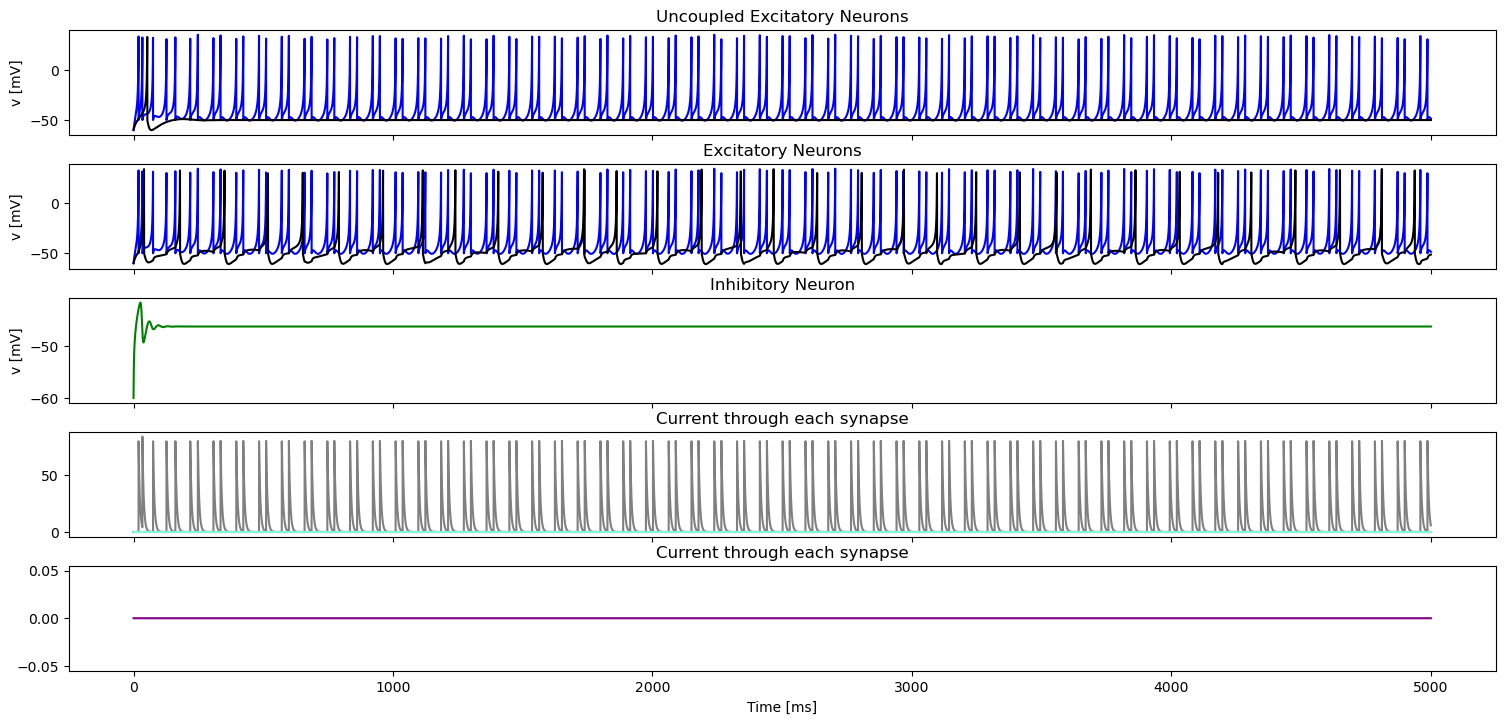

In [32]:
### Plot the outputs
# Need some systematic way of analysing the outputs

fig, ax = plt.subplots(5, 1, figsize = (15, 7), sharex = True)
fig.tight_layout()

ax[0].plot(M_uncoupled.t/ms, M_uncoupled.v[0], c = 'blue', label = 'autaptic neuron')
ax[0].plot(M_uncoupled.t/ms, M_uncoupled.v[1], c = 'black', label = 'non-autaptic neuron')
ax[0].set_title('Uncoupled Excitatory Neurons')
ax[0].set_ylabel('v [mV]')

ax[1].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', label = 'autaptic neuron')
ax[1].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', label = 'non-autaptic neuron')
ax[1].set_title('Excitatory Neurons')
ax[1].set_ylabel('v [mV]')

ax[2].plot(M_v_I.t/ms, M_v_I.v[0], c = 'green', label = 'inhibitory neuron')
ax[2].set_title('Inhibitory Neuron')
ax[2].set_ylabel('v [mV]')

ax[3].plot(M_v_E.t/ms, M_v_E.Syn_exc[0], c = 'purple', label = 'E1 -> E2')
ax[3].plot(M_v_E.t/ms, M_v_E.Syn_exc[1], c = 'gray', label = 'E2 -> E1')
ax[3].plot(M_v_E.t/ms, M_v_E.Syn_inh[0], c = 'aquamarine', label = 'I -> E1/E2')
ax[3].set_title('Current through each synapse')

ax[4].plot(M_v_I.t/ms, M_v_I.Syn_exc[0], c = 'purple', label = 'E1/E2 -> I')
#ax[3].plot(M_v_I.t/ms, M_v_I.Syn_exc[1], c = 'gray', label = 'E2 -> I')
ax[4].set_title('Current through each synapse')
ax[4].set_xlabel('Time [ms]')

Text(0, 0.5, 'v [mV]')

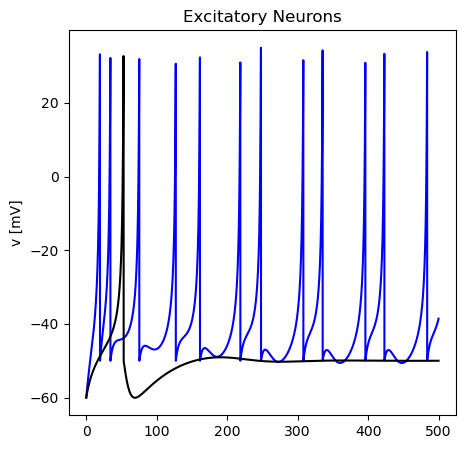

In [33]:
fig, ax = plt.subplots(1, 1, figsize = (5, 5))

ax.plot(M_uncoupled.t[:5000]/ms, M_uncoupled.v[0][:5000], c = 'blue', label = 'autaptic neuron')
ax.plot(M_uncoupled.t[:5000]/ms, M_uncoupled.v[1][:5000], c = 'black', label = 'non-autaptic neuron')
ax.set_title('Excitatory Neurons')
ax.set_ylabel('v [mV]')

350


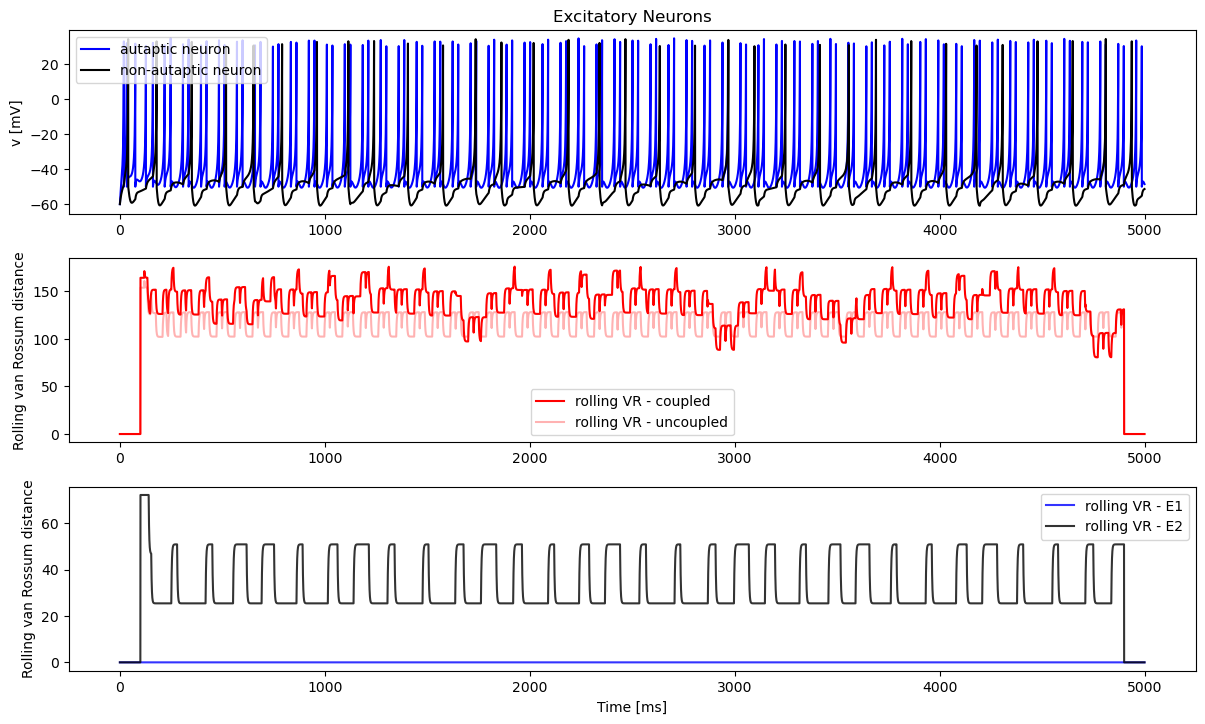

In [34]:
# Plot the membrane potentials and corresponding van rossum distance
spikes_E = convert_spikes_to_aqua(spike_trains_E)
spikes_uncoupled = convert_spikes_to_aqua(spike_trains_uncoupled)
spikes_I = convert_spikes_to_aqua(spike_trains_I)
bin_E = binarise_spikes(spikes_E, dt, N_iter)
bin_I = binarise_spikes(spikes_I, dt, N_iter)
bin_uncoupled = binarise_spikes(spikes_uncoupled, dt, N_iter)

# define filter
tau = 5     # ms
T_filter = 7 * tau
filter_length = int(T_filter/dt)
print(filter_length)
filter = np.exp(-np.linspace(0, T_filter, filter_length)/tau)

# get the rolling VR distance
window = 2000
VR = rolling_VR_dist(bin_E[0, :], bin_E[1, :], filter, window)
VR_uncoupled = rolling_VR_dist(bin_uncoupled[0, :], bin_uncoupled[1, :], filter, window)
VR_E1 = rolling_VR_dist(bin_uncoupled[0, :], bin_E[0, :], filter, window)
VR_E2 = rolling_VR_dist(bin_uncoupled[1, :], bin_E[1, :], filter, window)

fig, ax = plt.subplots(3, 1, figsize = (12, 7))
fig.tight_layout()

ax[0].plot(M_v_E.t/ms, M_v_E.v[0], c = 'blue', label = 'autaptic neuron')
ax[0].plot(M_v_E.t/ms, M_v_E.v[1], c = 'black', label = 'non-autaptic neuron')
ax[0].set_title('Excitatory Neurons')
ax[0].set_ylabel('v [mV]')
ax[0].legend()

ax[1].plot(M_v_E.t/ms, VR, c = 'red', label = 'rolling VR - coupled')
ax[1].plot(M_v_E.t/ms, VR_uncoupled, c = 'red', alpha = 0.3, label = 'rolling VR - uncoupled')
ax[1].set_ylabel('Rolling van Rossum distance')
ax[1].legend()

ax[2].plot(M_v_E.t/ms, VR_E1, c = 'blue', alpha = 0.8, label = 'rolling VR - E1')
ax[2].plot(M_v_E.t/ms, VR_E2, c = 'black', alpha = 0.8, label = 'rolling VR - E2')
ax[2].set_ylabel('Rolling van Rossum distance')
ax[2].set_xlabel('Time [ms]')
ax[2].legend()


Text(0, 0.5, 'Difference')

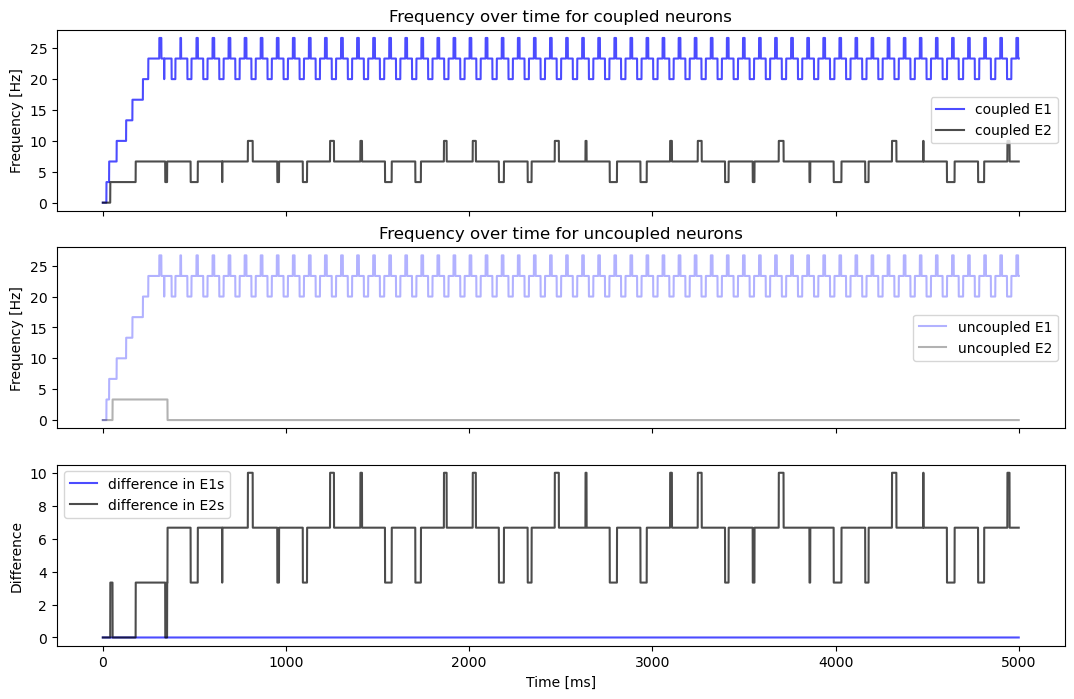

In [35]:
## Plot the frequency over time and compare to the uncoupled system
filter_duration = 300 # ms
filter_length = int(filter_duration/dt)
step_filter = np.ones(filter_length)*(1000/filter_duration)     # convert to seconds
freqE1 = np.convolve(bin_E[0, :], step_filter)[:len(bin_E[0, :])]
freqE2 = np.convolve(bin_E[1, :], step_filter)[:len(bin_E[1, :])]
freqE1_uncoupled = np.convolve(bin_uncoupled[0, :], step_filter)[:len(bin_uncoupled[0, :])]
freqE2_uncoupled = np.convolve(bin_uncoupled[1, :], step_filter)[:len(bin_uncoupled[1, :])]


fig, ax = plt.subplots(3, 1, figsize = (13, 8), sharex = True)

ax[0].plot(M_v_E.t/ms, freqE1, c = 'blue', alpha = 0.7, label = 'coupled E1')
ax[0].plot(M_v_E.t/ms, freqE2, c = 'black', alpha = 0.7, label = 'coupled E2')
ax[0].legend()

ax[1].plot(M_v_E.t/ms, freqE1_uncoupled, c = 'blue', alpha = 0.3, label = 'uncoupled E1')
ax[1].plot(M_v_E.t/ms, freqE2_uncoupled, c = 'black', alpha = 0.3, label = 'uncoupled E2')
ax[1].legend()

ax[2].plot(M_v_E.t/ms, freqE1 - freqE1_uncoupled, c = 'blue', alpha = 0.7, label = 'difference in E1s')
ax[2].plot(M_v_E.t/ms, freqE2 - freqE2_uncoupled, c = 'black', alpha = 0.7, label = 'difference in E2s')
ax[2].legend()

ax[0].set_title('Frequency over time for coupled neurons')
ax[1].set_title('Frequency over time for uncoupled neurons')
ax[2].set_xlabel('Time [ms]')
ax[0].set_ylabel('Frequency [Hz]')
ax[1].set_ylabel('Frequency [Hz]')
ax[2].set_ylabel('Difference')